# Nigerian SME Financial Vulnerability Segmentation

**Problem Statement:**
This project reimagines credit analysis for Nigerian SMEs as a segmentation problem rather than a classification problem. Using 2 million SME loan records from the Nigerian banking market (2021-2024), I engineer vulnerability-specific financial features : debt service ratio, collateral coverage, interest burden, and revenue productivity, then apply variance-based feature selection, PCA for dimensionality reduction, and k-means clustering to group small businesses into financially distinct subgroups.

This project demonstrates that unsupervised learning can surface structural patterns in SME finance that binary default prediction models routinely miss : revealing *who* is financially fragile, not just *whether* they will default.

---
**Dataset:** `electricsheepafrica/africa-synth-banking-sme-loans-nigeria`


## I Start by Importing the Necessary Libraries


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from datasets import load_dataset
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from scipy.stats.mstats import trimmed_var
import math
from sklearn.metrics import silhouette_score
from sklearn.pipeline import make_pipeline
from sklearn.utils.validation import check_is_fitted
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.utils import resample


## 1. Data Loading

Load the dataset from HuggingFace and convert to a pandas DataFrame for analysis.


In [ ]:
# Load dataset from HuggingFace
dataset = load_dataset("electricsheepafrica/africa-synth-banking-sme-loans-nigeria")
df = dataset["train"].to_pandas()

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.64k [00:00<?, ?B/s]

nigerian_sme_loans_full.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000000 [00:00<?, ? examples/s]

Shape: (2000000, 17)
Columns: ['loan_id', 'application_date', 'disbursement_date', 'business_id', 'business_sector', 'business_state', 'years_in_business', 'annual_revenue_ngn', 'num_employees', 'principal_ngn', 'interest_rate_annual', 'tenor_months', 'lender', 'collateral_value_ngn', 'credit_score', 'default_90d', 'default_180d']


In [ ]:
# Preview the first 5 rows
# this is done to get a broader feel of the dataset and make sure we import the correct thing.
df.head()

,loan_id,application_date,disbursement_date,business_id,business_sector,business_state,years_in_business,annual_revenue_ngn,num_employees,principal_ngn,interest_rate_annual,tenor_months,lender,collateral_value_ngn,credit_score,default_90d,default_180d
0,SME-0000829993,2023-08-03,2023-08-12,BIZ-00829993,retail_trade,Benue,5,1.796679e+07,7,2.756082e+06,0.229650,12,Access Bank,3.637618e+06,582,False,False
1,SME-0001116952,2022-02-04,2022-03-06,BIZ-01116952,services,Rivers,0,2.509480e+06,11,9.055391e+05,0.338573,12,Stanbic IBTC,1.791234e+06,495,False,False
2,SME-0001445480,2024-12-20,2025-01-03,BIZ-01445480,services,Oyo,2,1.350792e+06,12,1.362816e+06,0.305106,12,First Bank of Nigeria,1.646241e+06,588,True,True
3,SME-0000465969,2022-12-08,2022-12-25,BIZ-00465969,manufacturing,Lagos,5,2.195693e+07,5,6.593180e+06,0.269295,24,Access Bank,1.378757e+07,492,False,False
4,SME-0001466631,2021-09-07,2021-09-26,BIZ-01466631,retail_trade,Edo,0,6.390602e+06,6,4.763643e+06,0.296228,6,GTBank (Guaranty Trust),6.684086e+06,694,True,True


In [ ]:
# Check data types and confirm presence of null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 17 columns):
 #   Column                Dtype         
---  ------                -----         
 0   loan_id               object        
 1   application_date      datetime64[ns]
 2   disbursement_date     datetime64[ns]
 3   business_id           object        
 4   business_sector       object        
 5   business_state        object        
 6   years_in_business     int64         
 7   annual_revenue_ngn    float64       
 8   num_employees         int64         
 9   principal_ngn         float64       
 10  interest_rate_annual  float64       
 11  tenor_months          int64         
 12  lender                object        
 13  collateral_value_ngn  float64       
 14  credit_score          int64         
 15  default_90d           bool          
 16  default_180d          bool          
dtypes: bool(2), datetime64[ns](2), float64(4), int64(4), object(5)
memory usage: 232.7+ 

## 2. Feature Engineering
I Engineered feature from original columns. this is done to increase the richness of the dataset.

These ratios are standard in credit analysis and capture relationships
that raw columns alone cannot express.

| Feature | Formula | Business Meaning |
|---|---|---|
| `loan_to_rev_ratio` | principal / annual_revenue | Borrowing appetite vs capacity |
| `collateral_coverage_ratio` | collateral / principal | How well the loan is secured |
| `monthly_repayment_est` | principal / tenor | Monthly cash outflow (₦) |
| `revenue_per_employee` | annual_revenue / num_employees | Business productivity |
| `debt_service_ratio` | monthly_repayment / monthly_revenue | Repayment pressure vs income |

In [ ]:
# Engineering new features
df["loan_to_rev_ratio"]          = df["principal_ngn"] / df["annual_revenue_ngn"]
df["collateral_coverage_ratio"]  = df["collateral_value_ngn"] / df["principal_ngn"]
df["monthly_repayment_est"]      = df["principal_ngn"] / df["tenor_months"]
df["revenue_per_employee"]       = df["annual_revenue_ngn"] / df["num_employees"]
df["debt_service_ratio"]         = (df["principal_ngn"] / df["tenor_months"]) / (df["annual_revenue_ngn"] / 12)

print("Features engineered successfully.")
print(f"DataFrame now has {df.shape[1]} columns.")

Features engineered successfully.
DataFrame now has 22 columns.


##3. Exploratory Data Analysis (EDA)

I explored the data to understand distributions, sector-level patterns,
and which features show meaningful variation across the dataset.

> All original and engineered columns are available here.

### 3.1 Business Sector Distribution

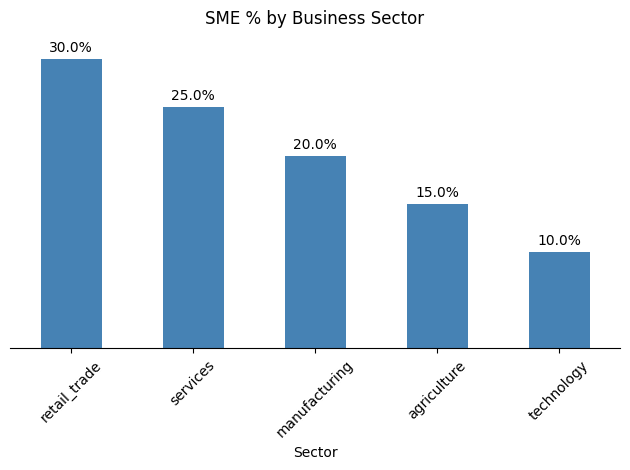

In [ ]:
# 1. Capture the axes object (ax) when plotting
ax = ((df["business_sector"].value_counts() / len(df)) * 100).plot(
    kind="bar", color="steelblue"
)

# 2. Add the data labels (ax.containers[0] automatically finds the bars)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)

# 3. Remove the y-axis completely
ax.yaxis.set_visible(False)

# 4. Remove the spine (border) on the left and top for a cleaner look
for spine in ["left", "top", "right"]:
    ax.spines[spine].set_visible(False)

# Formatting the rest of the plot
plt.title("SME % by Business Sector", pad=15)
plt.xlabel("Sector")
plt.xticks(rotation=45)
plt.tight_layout()

# Save and show
plt.savefig("SME % by business sector.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#retail trade takes up 30% of our data, closely followed by services, which makes up 25% of our dataset. Tech companies were the company that borrowed the least.

### 3.2 — Credit Score Distribution

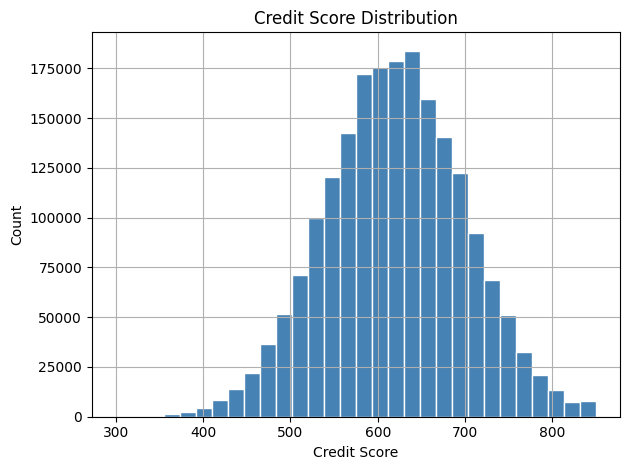

In [ ]:
df["credit_score"].hist(bins=30, color="steelblue", edgecolor="white")
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("Credit Score Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.3 — Years in Business Distribution

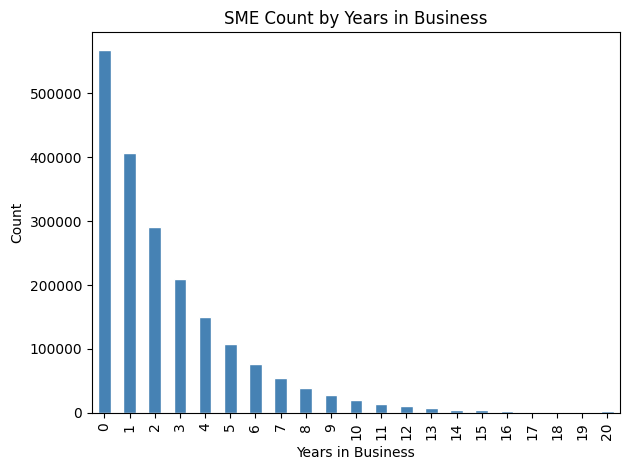

In [ ]:
df["years_in_business"].value_counts().sort_index().plot(
    kind="bar", color="steelblue", edgecolor="white"
)
plt.title("SME Count by Years in Business")
plt.xlabel("Years in Business")
plt.ylabel("Count")
plt.tight_layout()

plt.savefig("SME total by years in business.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.4 — Number of Employees Distribution

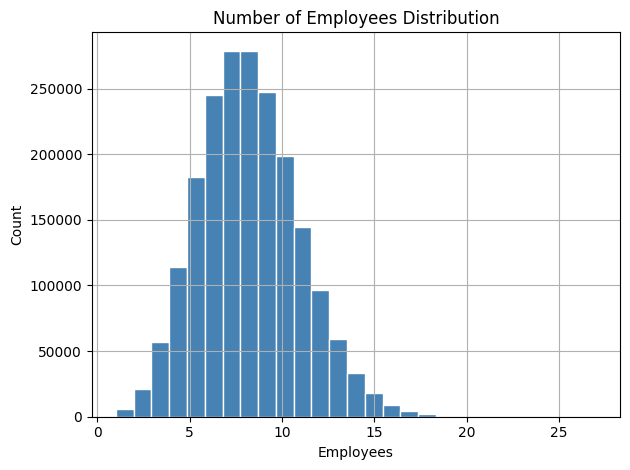

In [ ]:
df["num_employees"].hist(bins=27, color="steelblue", edgecolor="white")
plt.title("Number of Employees Distribution")
plt.xlabel("Employees")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("Number of Employees distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.5 — Loan Tenor Distribution

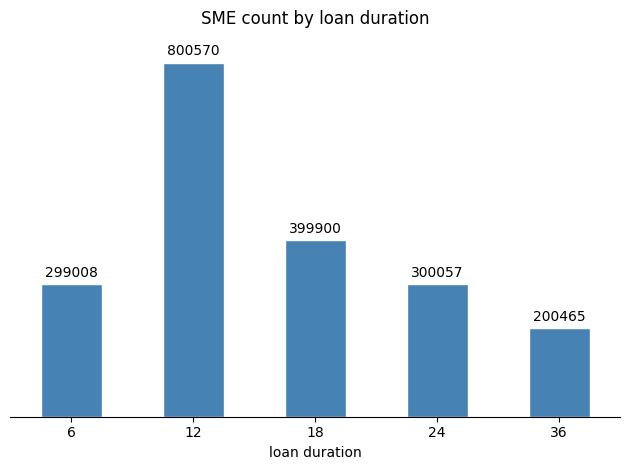

In [ ]:
ax= (df["tenor_months"].value_counts().sort_index().plot(
    kind="bar", color="steelblue", edgecolor="white"
))
# 2. Add the data labels (formatted as integers since this is a count)
ax.bar_label(ax.containers[0], fmt="%d", padding=3)

# 3. Remove the y-axis
ax.yaxis.set_visible(False)

# 4. Clean up the borders (spines) for a modern look
for spine in ["left", "top", "right"]:
    ax.spines[spine].set_visible(False)

# Formatting the rest of the plot
plt.title("SME count by loan duration", pad=15)
plt.xlabel("loan duration")
plt.xticks(rotation=0)
plt.tight_layout()

# Show or save
plt.savefig("SME count by loan duration.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# 800,570 of loans had duration of 12 months (1 year)

### 3.6 — Total Lending Volume by Sector

Total Lending Volume by Sector:
business_sector
retail_trade     1.211454e+12
services         1.008045e+12
manufacturing    8.056480e+11
agriculture      6.024333e+11
technology       4.052552e+11
Name: principal_ngn, dtype: float64


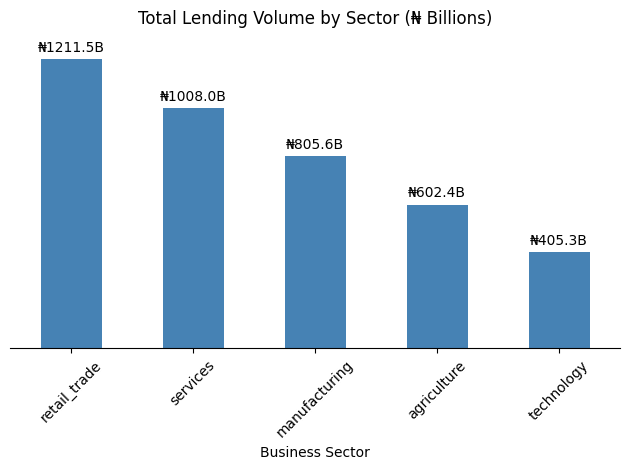

In [ ]:
# 1. Calculate the sum as usual
sector_volume = df.groupby("business_sector")["principal_ngn"].sum().sort_values(ascending=False)
print("Total Lending Volume by Sector:")
print(sector_volume)

# 2. Divide by 1,000,000,000 to convert to Billions for the plot
sector_volume_b = sector_volume / 1e9

# 3. Capture the axes object
ax = sector_volume_b.plot(kind="bar", color="steelblue")

# 4. Add data labels formatted with a 'B' suffix (e.g., 1,200.5B or 45B)
# '.1f' gives one decimal place. Change to '.0f' if you want whole numbers.
ax.bar_label(ax.containers[0], fmt="₦%.1fB", padding=3)

# 5. Remove the y-axis
ax.yaxis.set_visible(False)

# 6. Clean up the borders
for spine in ["left", "top", "right"]:
    ax.spines[spine].set_visible(False)

# Formatting the rest of the plot
plt.title("Total Lending Volume by Sector (₦ Billions)", pad=15)
plt.xlabel("Business Sector")
plt.xticks(rotation=45)
plt.tight_layout()

# save
plt.savefig("Total Lending Volume by Sector", dpi=300, bbox_inches='tight')
# Show
plt.show()

### 3.8 Correlation Matrix

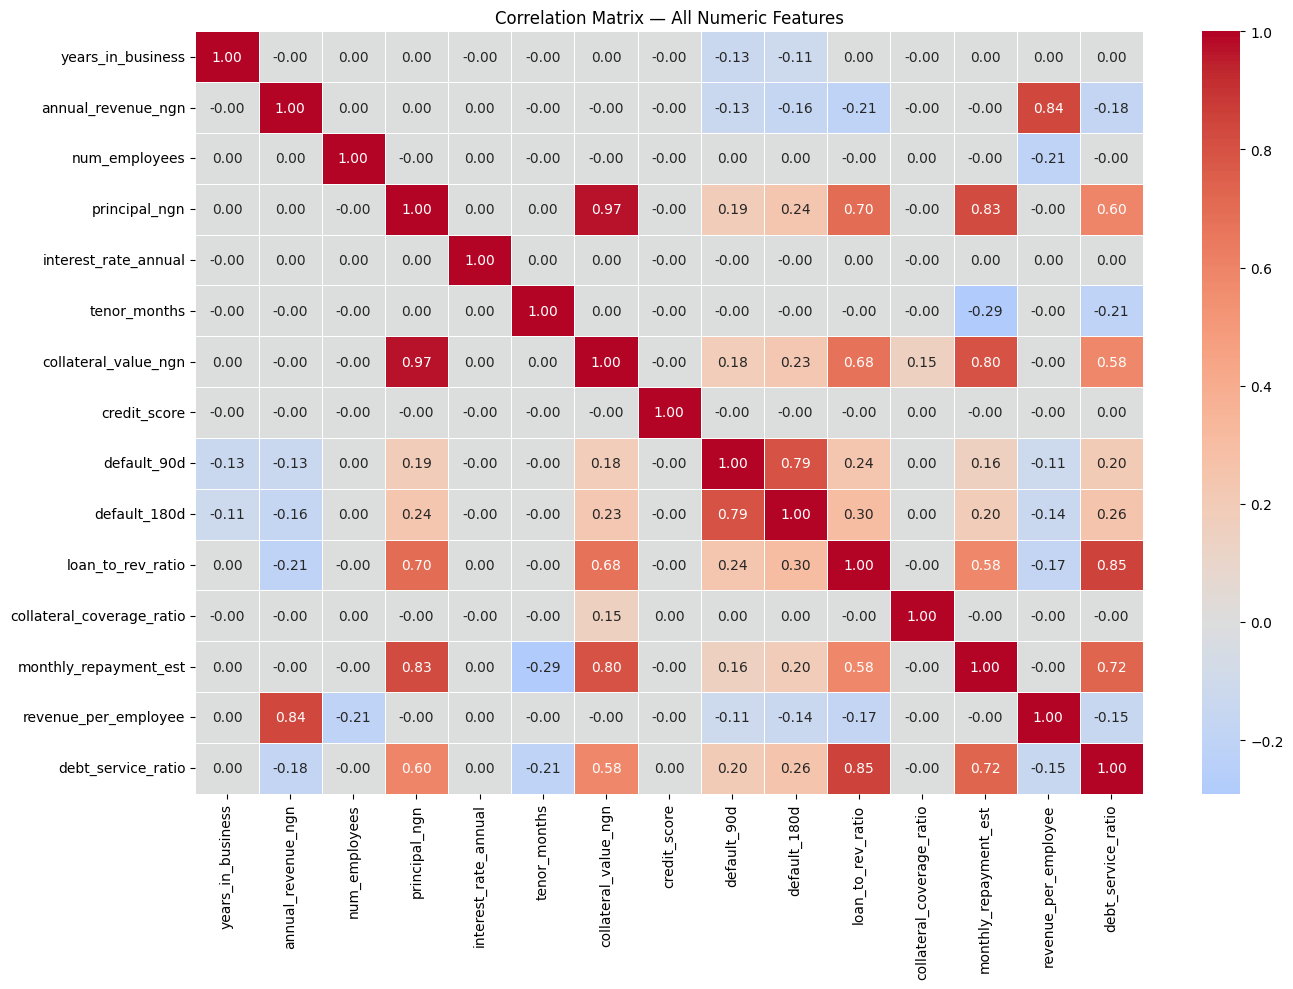

In [ ]:
# Compute correlation on all numeric columns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Matrix — All Numeric Features")
plt.tight_layout()
# save
plt.savefig("correlation Matrix", dpi=300, bbox_inches='tight')
# show
plt.show()

In [ ]:
# Key high correlations to note (above 0.85):
# principal_ngn <-> collateral_value_ngn : ~0.968  → keep collateral_coverage_ratio, i will remove collateral_value_ngn from clustering features
# annual_revenue_ngn <-> revenue_per_employee : ~0.843  → keep revenue_per_employee, i will remove annual_revenue_ngn from clustering features
# debt_service_ratio <-> loan_to_rev_ratio : ~0.855  → keep debt_service_ratio, i will remove loan_to_rev_ratio from clustering features
# monthly_repayment_est <-> principal_ngn : ~0.828  → keep principal_ngn, i will remove monthly_repayment_est from clustering features
# default_90d <-> default_180d : ~0.793  → both excluded from clustering

## Phase 4 Preprocessing

### Feature Selection Rationale

Based on the correlation chart and EDA findings, i define a clean set of
9 clustering features that:
- Contain no critical redundancy (no pair above 0.85 correlation)
- Exclude default columns.
- Exclude raw columns made redundant by their engineered ratios.

**Excluded from clustering (but kept in dataframe):**
- `default_90d`, `default_180d` — validation only
- `collateral_value_ngn` — replaced by `collateral_coverage_ratio`
- `annual_revenue_ngn` — replaced by `revenue_per_employee`
- `loan_to_rev_ratio` — made redundant by `debt_service_ratio`
- `monthly_repayment_est` — component of `debt_service_ratio`


In [ ]:
# Define explicit clustering feature list
clustering_features = [
    'years_in_business',
    'num_employees',
    'principal_ngn',
    'interest_rate_annual',
    'tenor_months',
    'credit_score',
    'collateral_coverage_ratio',
    'revenue_per_employee',
    'debt_service_ratio'
]

# Subset only clustering features
X = df[clustering_features].copy()

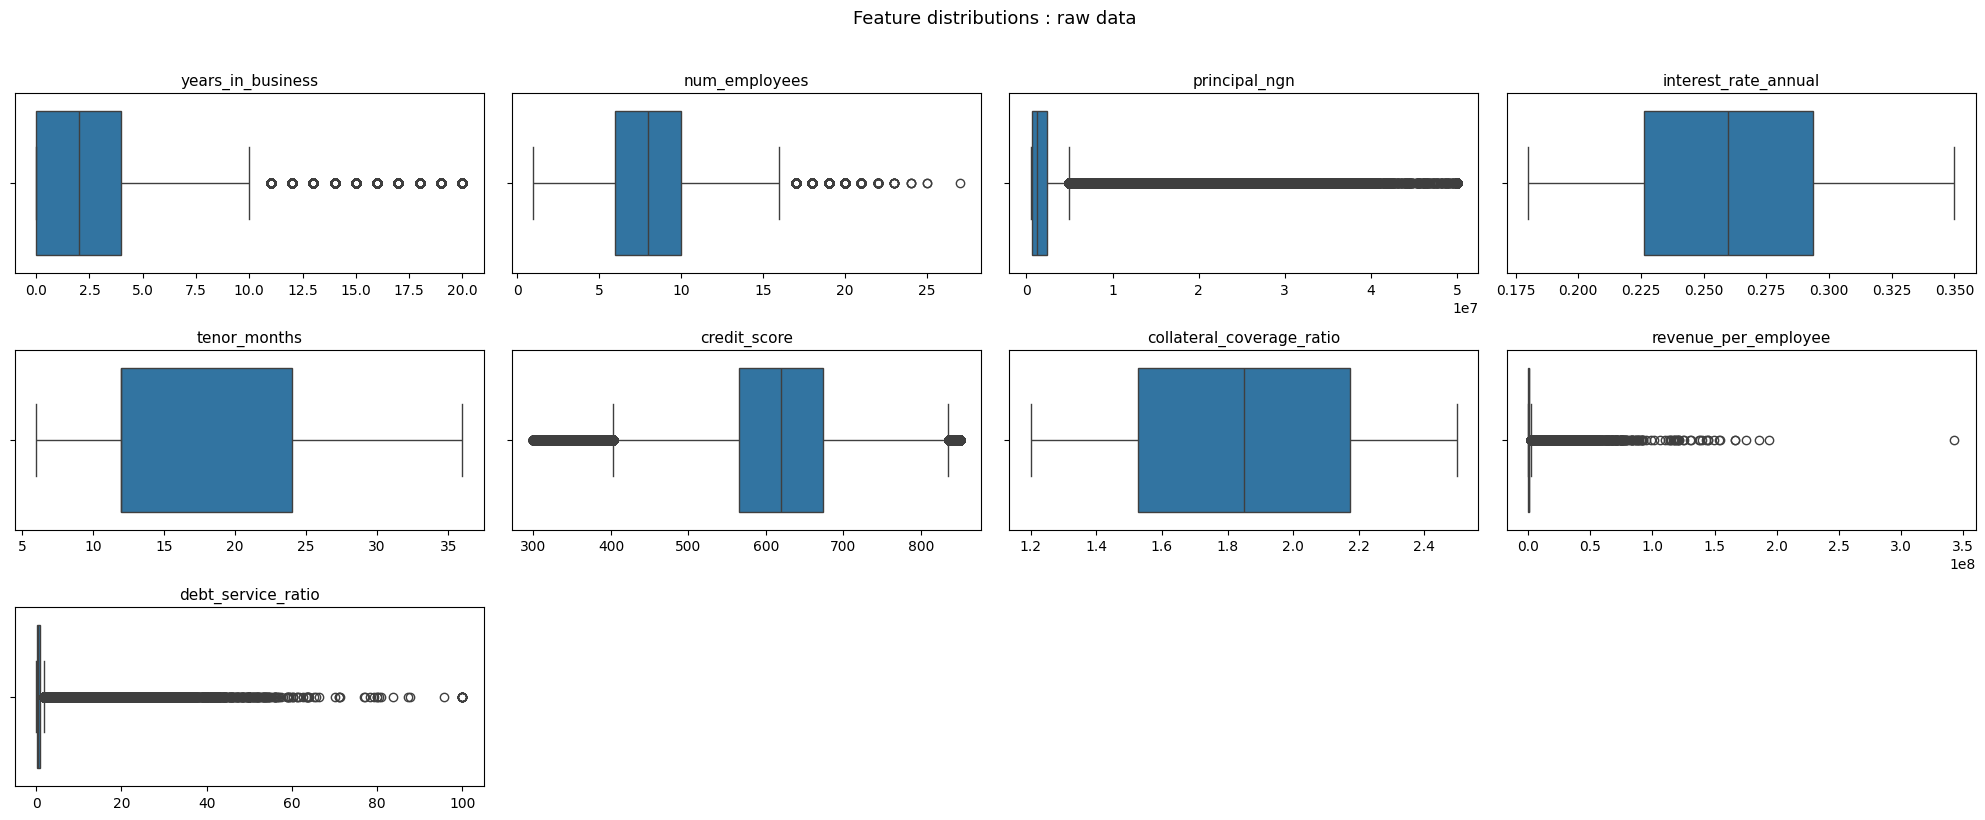

In [ ]:
features = X.columns.tolist()
n_cols = 4
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=X, x=feature, ax=axes[i])
    axes[i].set_title(feature, fontsize=11)
    axes[i].set_xlabel("")

# hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature distributions : raw data", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("Feature distributions", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
cap_rules = {
    "principal_ngn": 0.90,
    "revenue_per_employee": 0.90,
    "debt_service_ratio": 0.90,
    "years_in_business": 0.99,
    "num_employees": 0.99,
}

X_capped = X.copy()
for feature, quantile in cap_rules.items():
    cap = X_capped[feature].quantile(quantile)
    X_capped[feature] = X_capped[feature].clip(upper=cap)

In [ ]:
# Apply the custom trimmed variance function across all columns in the capped dataframe.
# This calculates the variance of each feature while ignoring a specified percentage
# of extreme values at both ends of the distribution, ensuring that any residual
# outliers do not artificially inflate the variance metrics.
X_capped.apply(trimmed_var)

,0
years_in_business,2.979830e+00
num_employees,3.509949e+00
principal_ngn,9.194664e+11
interest_rate_annual,1.097894e-03
tenor_months,2.693467e+01
credit_score,2.800990e+03
collateral_coverage_ratio,8.988681e-02
revenue_per_employee,2.448839e+11
debt_service_ratio,1.813080e-01


In [ ]:
# Initialize the standard scaler tool
scaler = StandardScaler()

# Scale data to mean=0 and variance=1, then convert back to a DataFrame
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_capped),
    columns=X_capped.columns
)

# Compute the trimmed variance for each scaled feature
trimmed_vars = X_scaled.apply(trimmed_var)

# Display the trimmed variances sorted from highest to lowest
print(trimmed_vars.sort_values(ascending=False))

collateral_coverage_ratio    0.639450
principal_ngn                0.572607
revenue_per_employee         0.522631
interest_rate_annual         0.517960
debt_service_ratio           0.510381
num_employees                0.452532
credit_score                 0.439831
tenor_months                 0.376230
years_in_business            0.372010
dtype: float64


In [ ]:
# Create a horizontal bar chart using the trimmed variances and feature names
fig = px.bar(
    x=trimmed_vars.sort_values(),
    y=trimmed_vars.index,
    title="High Variance Features"
)

# Update the axis labels for clarity
fig.update_layout(xaxis_title="variance", yaxis_title="Features")

# Render and display the interactive plot
fig.show()

In [ ]:
# Set the minimum acceptable trimmed variance threshold
threshold = 0.40

# Filter for features above the threshold and save their names to a list
selected_features = trimmed_vars[trimmed_vars > threshold].index.tolist()

# Extract only the high-variance features from the scaled dataset
X_features = X_scaled[selected_features]

In [ ]:
# Calculate the mean and standard deviation for the selected features and convert to integers
X_summary = X_features.aggregate(["mean", "std"]).astype(int)

# Display the summary table to check if scaling worked (mean should be 0, std should be 1)
X_summary

,num_employees,principal_ngn,interest_rate_annual,credit_score,collateral_coverage_ratio,revenue_per_employee,debt_service_ratio
mean,0,0,0,0,0,0,0
std,1,1,1,1,1,1,1


In [ ]:
# Define the range of clusters to evaluate from 2 to 14
n_clusters = range(2, 15)

# Initialize empty lists to store the performance metrics for each cluster size
inertia_errors = []
silhouette_scores = []

# Downsample the data to 50,000 samples to speed up calculations while preserving the distribution
X_sample = resample(X_features, n_samples=50_000, random_state=42)

# Loop through each cluster count to evaluate model performance
for k in n_clusters:
    # Build a pipeline that scales the sampled data and applies KMeans clustering
    model = make_pipeline(
        StandardScaler(), KMeans(n_clusters=k, random_state=42, n_init=5)
    )

    # Fit the pipeline to the sampled data
    model.fit(X_sample)

    # Extract and store the inertia (sum of squared distances to the nearest cluster center)
    inertia_errors.append(model.named_steps["kmeans"].inertia_)

    # Calculate and store the silhouette score using a 10,000 sample subset for performance
    silhouette_scores.append(
        silhouette_score(
            X_sample,
            model.named_steps["kmeans"].labels_,
            sample_size=10_000,
            random_state=42,
        )
    )

In [52]:
# Create a line plot comparing the number of clusters against the inertia errors
fig = px.line(x=n_clusters, y=inertia_errors, title="custers aganist inertia")
fig.update_xaxes(dtick=1)

# Save the interactive line chart as an HTML file named after the title
fig.write_html("custers aganist inertia.html")

# Render and display the interactive plot
fig.show()

In [53]:
# Create a line plot comparing the number of clusters against the silhouette scores
fig = px.line(x=n_clusters, y=silhouette_scores, title="custers aganist silhouette_scores")
fig.update_xaxes(dtick=1)


# Render and display the interactive plot
fig.show()

In [ ]:
# Build the final pipeline using the optimal cluster count of 3
final_model = make_pipeline(
    KMeans(n_clusters=3, random_state=42, n_init=10)
)

# Fit the pipeline to the selected high-variance features dataset
final_model.fit(X_features)

Pipeline(steps=[('kmeans', KMeans(n_clusters=3, n_init=10, random_state=42))])

In [ ]:
# Verify that the final model has been successfully fitted with data
check_is_fitted(final_model)

In [ ]:
# Extract the assigned cluster labels for each data point from the fitted KMeans step
labels = final_model.named_steps["kmeans"].labels_

# Group the high-variance features by these labels and calculate the mean for each group to profile the clusters
cluster_profile = X_features.groupby(labels).mean()

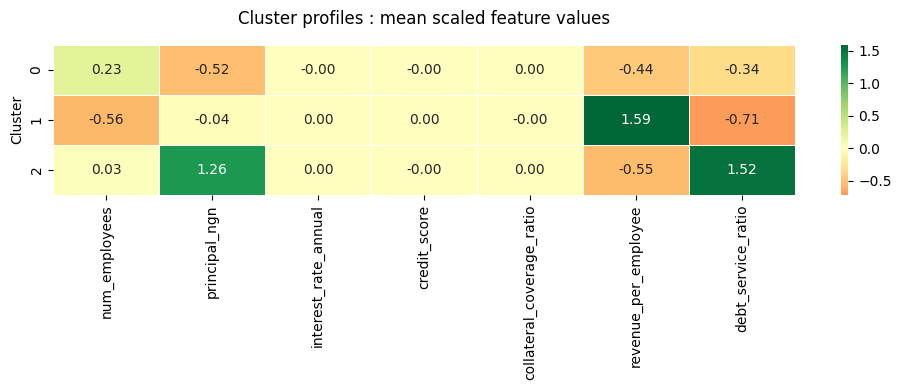

In [ ]:
# Set the dimensions for a wide and readable plot window
plt.figure(figsize=(10, 4))

# Generate a heatmap using the mean scaled values to easily spot patterns across clusters
sns.heatmap(
    cluster_profile,
    annot=True,         # Display the exact numeric mean value inside each cell
    fmt=".2f",          # Limit numeric labels to two decimal places
    cmap="RdYlGn",      # Use a Red-Yellow-Green color scale to highlight relative highs and lows
    center=0,           # Center the color scale color at 0 (the standard scaling mean)
    linewidths=0.5      # Add subtle grid borders between the heatmap cells
)

# Apply a descriptive header for the visualization
title_text = "Cluster profiles : mean scaled feature values"
plt.title(title_text, pad=15)

# Label the y-axis to indicate rows represent individual clusters
plt.ylabel("Cluster")

# Optimize spacing around borders to ensure text labels are not cut off
plt.tight_layout()

# Save the generated heatmap using the exact title text as the filename
filename = f"{title_text}.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')

# Render and display the final chart
plt.show()

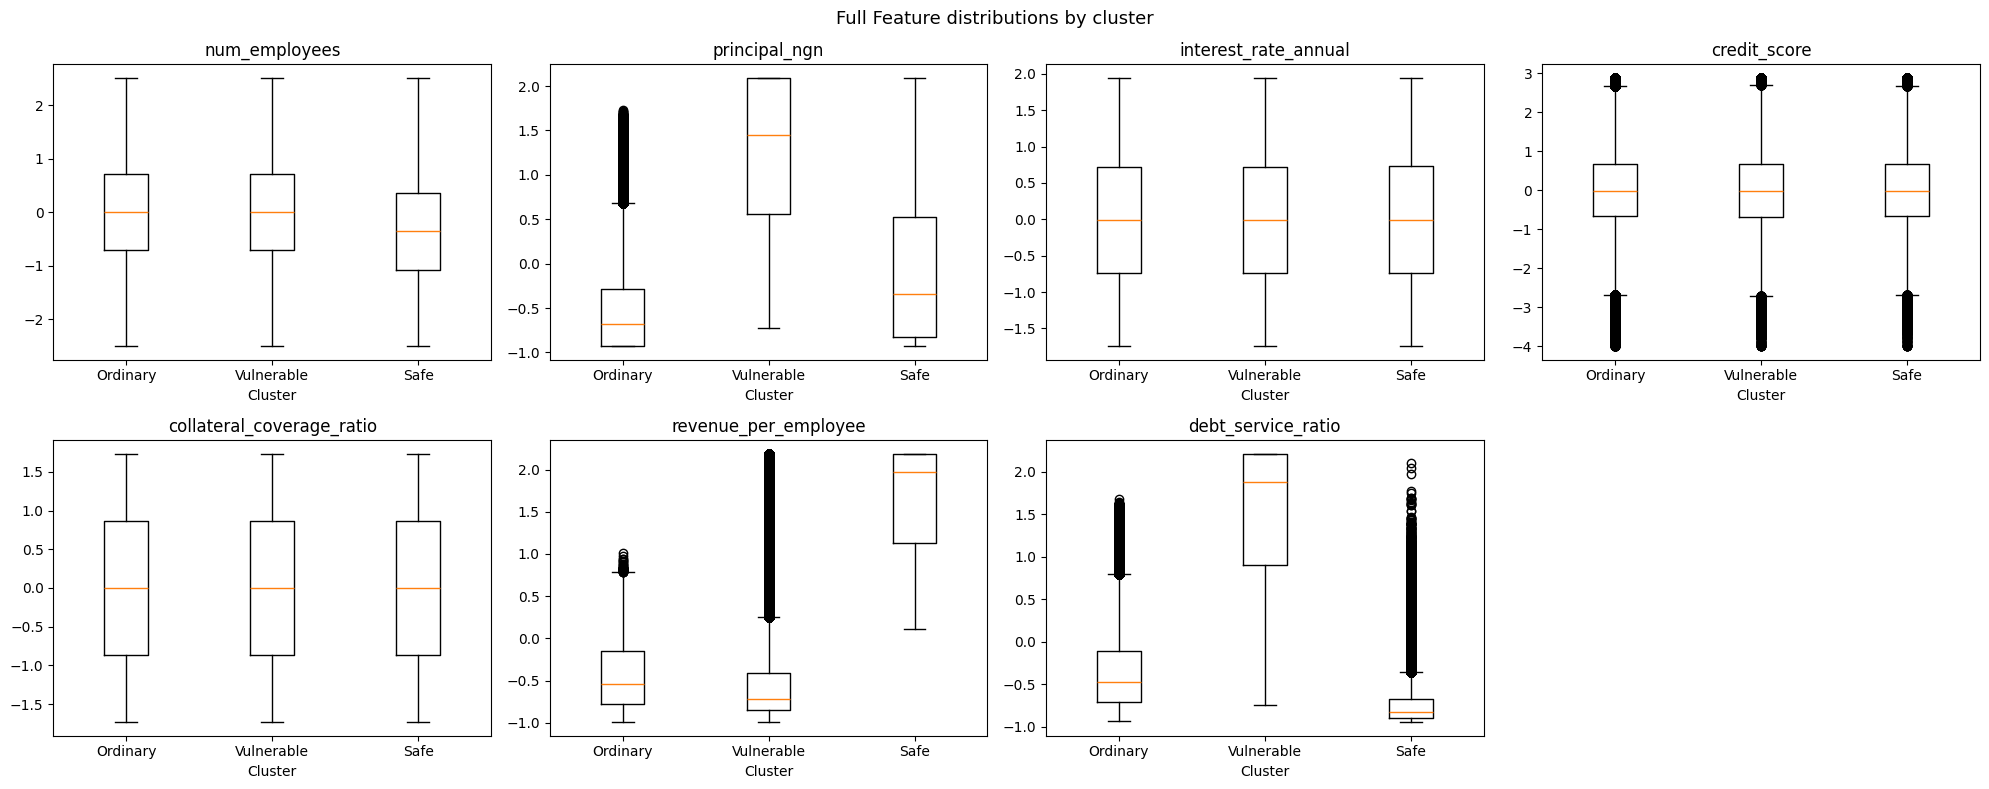

In [56]:
# Create a copy of the dataset to safely add labels without altering the original data
X_plot = X_features.copy()

# Add the cluster assignment labels as a new column in the copied dataframe
X_plot["cluster"] = labels

# Initialize a grid of subplots with 2 rows and 4 columns
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 8))

# Flatten the 2D grid array into a 1D array for easier iteration
axes = axes.flatten()

# Generate boxplots for each selected high-variance feature grouped by cluster
for i, feature in enumerate(selected_features):
    # Pass data subsets for each cluster into the boxplot function and map their profile names
    axes[i].boxplot(
        [X_plot[X_plot["cluster"] == c][feature].values for c in [0, 1, 2]],
        tick_labels=["Ordinary", "Vulnerable", "Safe"],
    )

    # Set the feature name as the title for each subplot
    axes[i].set_title(feature)

    # Set the x-axis label to clarify the grouping variable
    axes[i].set_xlabel("Cluster")

# Hide any remaining subplot spaces that do not contain a feature plot
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Add an overarching main title above the entire grid of subplots
plt.suptitle("Full Feature distributions by cluster", fontsize=13)

# Adjust the layout spacing to prevent titles, tick marks, and axes from overlapping
plt.tight_layout()

# Save the multi-panel figure using the main title as the filename before displaying it
plt.savefig(" Full Feature distributions by cluster.png", dpi=300, bbox_inches="tight")

# Render and display the final set of charts
plt.show()

In [ ]:
# Compute the silhouette score on a 20,000-sample subset using a 10,000-sample evaluation slice
score = silhouette_score(
    X_features[selected_features].sample(20000, random_state=42),
    np.array(labels)[X_features[selected_features].sample(20000, random_state=42).index],
    sample_size=10000,
    random_state=42
)

# Print the final silhouette score formatted to four decimal places
print(f"Silhouette score: {score:.4f}")

Silhouette score: 0.1885


In [ ]:
# Compute the silhouette score across the full feature dataset using a 100,000-sample internal slice
score = silhouette_score(
    X_features[selected_features],
    labels,
    sample_size=100000,  # samples internally, still uses full label array
    random_state=42,
)

# Print the final validation metric formatted to four decimal places
print(f"Silhouette score: {score:.4f}")

Silhouette score: 0.1907


In [54]:
# Define a subset of the most critical variables for focused cluster evaluation
initial_core_features = ["principal_ngn", "revenue_per_employee", "debt_service_ratio","num_employees"]

# Compute the silhouette score isolating only these core features with a 50,000-sample slice
score = silhouette_score(
    X_features[initial_core_features], labels, sample_size=100000, random_state=42
)

# Print the subset validation metric formatted to four decimal places
print(f"Silhouette score (core features): {score:.4f}")

Silhouette score (core features): 0.3568


In [55]:
# Define a subset of the most critical variables for focused cluster evaluation
top_three_features = ["principal_ngn", "revenue_per_employee", "debt_service_ratio"]

# Compute the silhouette score isolating only these core features with a 50,000-sample slice
score = silhouette_score(
    X_features[top_three_features], labels, sample_size=100000, random_state=42
)

# Print the subset validation metric formatted to four decimal places
print(f"Silhouette score (core features): {score:.4f}")

Silhouette score (core features): 0.4842


In [58]:
# Define a subset of the most critical features for the revised model
core_features = ["principal_ngn", "revenue_per_employee", "debt_service_ratio"]

# Filter the dataset to include only the defined core features
X_core_features = X_features[core_features]

# Rebuild the pipeline using 3 clusters for the refined feature space
final_model = make_pipeline(KMeans(n_clusters=3, random_state=42, n_init=10))

# Fit the new pipeline specifically to the core features dataset
final_model.fit(X_core_features)

# Extract the newly generated cluster labels for each data point
labels = final_model.named_steps["kmeans"].labels_

In [59]:
# Count the number of data points assigned to each cluster and sort by cluster ID
pd.Series(labels).value_counts().sort_index()

,count
0,1103449
1,459727
2,436824
